<div style="border: 5px solid black; padding: 20px; border-radius: 6px;">

## **Course:** DSC680 - Applied Data Science
## **Name:** Tim Hollis
## **Assignment:** Project 1, Milestone 2 - Scam Signatures
## **Date:** September 20, 2026

---

**Reference**

Bansal, S. (2020). *Real or fake: Fake job posting prediction* [Data set]. Kaggle. https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction

</div>

### **Initial Setup**

In [1]:
# Colab environment setup
!pip install -q sentence-transformers umap-learn hdbscan

import importlib
import sys

REQUIRED = ['sentence_transformers', 'umap', 'hdbscan']
missing = [m for m in REQUIRED if importlib.util.find_spec(m) is None]

if missing:
    print(f'❌ Not importable yet: {missing}')
    print('🔄 Runtime > Restart session, then run this cell again before continuing.')
else:
    print('✅ All clustering packages available')
    print(f'🐍 Python {sys.version.split()[0]}')

✅ All clustering packages available
🐍 Python 3.13.15


In [2]:
# Imports
import html
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

import hdbscan
import umap
from matplotlib.patches import Patch
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (adjusted_rand_score,
                             normalized_mutual_info_score,
                             silhouette_score)
from google.colab import drive

warnings.filterwarnings('ignore')

# Global settings
RANDOM_STATE = 42
EMBED_MODEL = 'all-MiniLM-L6-v2'
DATA_FILE = 'fake_job_postings.csv'
TEXT_FIELDS = ['title', 'company_profile', 'description',
               'requirements', 'benefits']
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Colorblind-safe palette
ROYAL_BLUE = '#4169E1'
PURPLE = '#4B0082'
FOREST_GREEN = '#228B22'
AMBER = '#E69F00'
LIGHT_GRAY = '#BFBFBF'
DARK_GRAY = '#595959'
PALETTE = [ROYAL_BLUE, AMBER, FOREST_GREEN, PURPLE, DARK_GRAY]

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
np.set_printoptions(suppress=True)

# Identities surfaced by the analysis, masked wherever output is displayed
REDACTED = ['Aptitude Staffing Solutions', 'Aptitude Staffing', 'Aptitude',
            'Refined Resources', 'Darren Lawson', 'Lawson',
            'Aker Solutions', 'Aker', 'AECOM', 'Expro', 'NETGEAR',
            'Desert Regional Medical Center', 'Tel Tech Networks',
            'Gabriel Adkins', 'Rohan', 'Maxim Staffing', 'Intercom']

_redact_pattern = re.compile('|'.join(re.escape(name) for name in
                                      sorted(REDACTED, key=len, reverse=True)),
                             flags=re.IGNORECASE)


def redact(text):
    """Replace named organizations and individuals in any displayed text."""
    return _redact_pattern.sub('[IDENTITY REDACTED]', str(text))


def redact_terms(terms):
    """Drop terms that are or contain a redacted identity."""
    return [t for t in terms if not _redact_pattern.search(t)]


print('🔒 Redaction active for', len(REDACTED), 'identities')
print('   self-test:', redact(REDACTED[0]))

# Locate the dataset, prompting an upload if it is not already here
drive.mount('/content/drive')
candidates = [Path(DATA_FILE),
              Path('/content/drive/MyDrive') / DATA_FILE,
              Path('/content/drive/MyDrive/DSC680') / DATA_FILE]
data_path = next((p for p in candidates if p.exists()), None)

if data_path is None:
    from google.colab import files
    print(f'📤 {DATA_FILE} not found. Choose it from your computer.')
    files.upload()
    data_path = Path(DATA_FILE)

df_raw = pd.read_csv(data_path)

print(f'✅ Setup complete, embedding model set to {EMBED_MODEL}')
print(f'⚡ Compute device: {DEVICE}')
print(f'📂 Loaded {data_path}')
print(f'📊 Raw dataset: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')
print(f'🚩 Fraud rate: {df_raw["fraudulent"].mean():.2%} '
      f'({df_raw["fraudulent"].sum():,} of {len(df_raw):,})')

🔒 Redaction active for 17 identities
   self-test: [IDENTITY REDACTED]
Mounted at /content/drive
✅ Setup complete, embedding model set to all-MiniLM-L6-v2
⚡ Compute device: cuda
📂 Loaded /content/drive/MyDrive/DSC680/fake_job_postings.csv
📊 Raw dataset: 17,880 rows, 18 columns
🚩 Fraud rate: 4.84% (866 of 17,880)


In [3]:
# Assemble each posting into one document and derive structural features
def clean_text(value):
    """Strip HTML, normalize EMSCAD placeholder tokens, collapse whitespace."""
    if not isinstance(value, str):
        return ''
    text = html.unescape(value)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'#URL_[0-9a-fA-F]+#', ' weblink ', text)
    text = re.sub(r'#EMAIL_[0-9a-fA-F]+#', ' emailaddress ', text)
    text = re.sub(r'#PHONE_[0-9a-fA-F]+#', ' phonenumber ', text)
    return re.sub(r'\s+', ' ', text).strip()


df = df_raw.copy()

# Presence flags come first, since a missing field is itself a signal
for field in TEXT_FIELDS:
    df[f'has_{field}'] = df[field].notna().astype(int)
df['has_salary'] = df['salary_range'].notna().astype(int)

# Contact tokens are counted before they are normalized away
contact_pattern = r'#(?:URL|EMAIL|PHONE)_[0-9a-fA-F]+#'
raw_joined = df[TEXT_FIELDS].fillna('').agg(' '.join, axis=1)
df['n_contact_tokens'] = raw_joined.str.count(contact_pattern)

# Build the single document that will be embedded
df['document'] = (df[TEXT_FIELDS]
                  .fillna('')
                  .apply(lambda row: ' '.join(clean_text(v) for v in row), axis=1)
                  .str.replace(r'\s+', ' ', regex=True)
                  .str.strip())

df['doc_length'] = df['document'].str.split().str.len()

print('🧱 Documents assembled from title, profile, description, requirements, benefits')
print(f'📏 Median document length: {df["doc_length"].median():,.0f} words')
print(f'📏 Shortest: {df["doc_length"].min():,} | Longest: {df["doc_length"].max():,} words')
print(f'📞 Postings containing a contact token: '
      f'{(df["n_contact_tokens"] > 0).mean():.1%}')
print('\n🕳 Field presence rates:')
for field in TEXT_FIELDS:
    print(f'   {field}: {df[f"has_{field}"].mean():.1%}')

🧱 Documents assembled from title, profile, description, requirements, benefits
📏 Median document length: 350 words
📏 Shortest: 2 | Longest: 2,118 words
📞 Postings containing a contact token: 36.4%

🕳 Field presence rates:
   title: 100.0%
   company_profile: 81.5%
   description: 100.0%
   requirements: 84.9%
   benefits: 59.7%


### **Data Quality Audit**

Before filtering, two checks establish what the data actually contains: whether very short postings carry signal or noise, and whether any postings labeled fraudulent are platform artifacts rather than scams.

In [4]:
# How many documents are too short to carry meaning, and are they fraud-skewed?
print('📉 Short document audit')
for threshold in [5, 10, 25, 50, 100]:
    subset = df[df['doc_length'] < threshold]
    print(f'   under {threshold:>4,} words: {len(subset):>5,} postings '
          f'({len(subset) / len(df):>5.1%}) | fraud rate {subset["fraudulent"].mean():>6.1%}')

print(f'\n📊 Baseline fraud rate: {df["fraudulent"].mean():.1%}')
print('\n🔍 Ten shortest documents:')
display(df.nsmallest(10, 'doc_length')[['title', 'doc_length', 'fraudulent', 'document']]
        .assign(title=lambda d: d['title'].map(redact),
                document=lambda d: d['document'].map(redact)))

# Do some postings labeled fraudulent look like platform test data rather than scams?
test_marker = df['document'].str.contains(r'\bRohan\b', case=False, na=False)
suspects = df[test_marker]

print(f'\n🧪 Postings matching the test-data marker: {len(suspects):,}')
print(f'🚩 Fraud rate among them: {suspects["fraudulent"].mean():.1%}')
print(f'📏 Median length: {suspects["doc_length"].median():,.0f} words')
print(f'📊 Share of all fraudulent postings: '
      f'{suspects["fraudulent"].sum() / df["fraudulent"].sum():.1%}')
print('\n🔍 Sample:')
display(suspects[['title', 'location', 'doc_length', 'fraudulent', 'document']]
        .assign(title=lambda d: d['title'].map(redact),
                document=lambda d: d['document'].map(redact)))

📉 Short document audit
   under    5 words:     2 postings ( 0.0%) | fraud rate 100.0%
   under   10 words:     6 postings ( 0.0%) | fraud rate  83.3%
   under   25 words:    45 postings ( 0.3%) | fraud rate  31.1%
   under   50 words:   155 postings ( 0.9%) | fraud rate  16.8%
   under  100 words: 1,344 postings ( 7.5%) | fraud rate   8.7%

📊 Baseline fraud rate: 4.8%

🔍 Ten shortest documents:


,title,doc_length,fraudulent,document
17513,Office Manager,2,1,Office Manager
11077,Real Services,4,1,Real Services See [IDENTITY REDACTED]
14270,Northwestern Hospital,5,1,Northwestern Hospital build a website
1242,Software Engineer,7,0,Software Engineer UI engineeringMachine learningWeb engineeringSystems engineering
11037,Migration Center,7,1,Migration Center Work with [IDENTITY REDACTED] to develop
180,Sales Executive,8,1,Sales Executive Sales Executive Sales Executive Sales Executive
7316,Ux desgin,10,1,"Ux desgin Best UX job in the world Axureillustrator 10,000$"
17756,Boys & Girls Club,10,1,Boys & Girls Club [IDENTITY REDACTED] will fill in these projects
14084,Catering Assistant,12,0,Catering Assistant An experienced catering assistant required for a fast food shop.
17534,Photoshop master,12,1,"Photoshop master We need a Photoshop master - AE adventage... PhotoshopAE 12,000$"



🧪 Postings matching the test-data marker: 3
🚩 Fraud rate among them: 100.0%
📏 Median length: 7 words
📊 Share of all fraudulent postings: 0.3%

🔍 Sample:


,title,location,doc_length,fraudulent,document
11037,Migration Center,NaN,7,1,Migration Center Work with [IDENTITY REDACTED] to develop
11077,Real Services,NaN,4,1,Real Services See [IDENTITY REDACTED]
17756,Boys & Girls Club,NaN,10,1,Boys & Girls Club [IDENTITY REDACTED] will fill in these projects


In [5]:
# Filter degenerate rows and remove exact duplicate postings
MIN_WORDS = 5
rows_start = len(df)

missing_desc = int(df['description'].isna().sum())
df = df[df['description'].notna()].copy()

too_short = int((df['doc_length'] < MIN_WORDS).sum())
df = df[df['doc_length'] >= MIN_WORDS].copy()

# Repetition is itself a scam behavior, so record it before collapsing copies
df['n_copies'] = df.groupby('document')['document'].transform('size')
dup_by_class = (df.assign(is_dupe=df['n_copies'] > 1)
                  .groupby('fraudulent')['is_dupe'].mean())

rows_before_dedupe = len(df)
duplicate_rows = int((df['n_copies'] > 1).sum())
duplicate_groups = int(df.loc[df['n_copies'] > 1, 'document'].nunique())
df = df.drop_duplicates(subset='document', keep='first').reset_index(drop=True)
duplicates_removed = rows_before_dedupe - len(df)

print('🧹 Building the modeling frame')
print(f'📐 Starting rows: {rows_start:,}')
print(f'🗑️  Dropped, missing description: {missing_desc:,}')
print(f'🗑️  Dropped, under {MIN_WORDS} words: {too_short:,}')
print(f'🔁 Duplicate documents: {duplicate_rows:,} rows across {duplicate_groups:,} groups')
print(f'🗑️  Dropped, exact duplicates: {duplicates_removed:,}')
print(f'✅ Modeling frame: {len(df):,} postings')
print(f'🚩 Fraud rate: {df["fraudulent"].mean():.2%} '
      f'({df["fraudulent"].sum():,} of {len(df):,})')
print('\n📊 Share of postings that were duplicated, by class:')
print(f'   legitimate: {dup_by_class.get(0, 0):.1%}')
print(f'   fraudulent: {dup_by_class.get(1, 0):.1%}')
print(f'📈 Most-copied document appeared {df["n_copies"].max():,} times')

🧹 Building the modeling frame
📐 Starting rows: 17,880
🗑️  Dropped, missing description: 1
🗑️  Dropped, under 5 words: 1
🔁 Duplicate documents: 2,747 rows across 741 groups
🗑️  Dropped, exact duplicates: 2,006
✅ Modeling frame: 15,872 postings
🚩 Fraud rate: 4.48% (711 of 15,872)

📊 Share of postings that were duplicated, by class:
   legitimate: 15.0%
   fraudulent: 22.3%
📈 Most-copied document appeared 375 times


In [6]:
# Which documents were reposted most, and does reposting track fraud?
print('📈 Most reposted documents')
display(df.nlargest(10, 'n_copies')[['title', 'location', 'industry',
                                     'n_copies', 'fraudulent', 'doc_length']]
        .assign(title=lambda d: d['title'].map(redact)))

print('\n📊 Fraud rate by repost volume:')
bands = [(1, 1), (2, 5), (6, 20), (21, 100), (101, 100_000)]
for low, high in bands:
    band = df[(df['n_copies'] >= low) & (df['n_copies'] <= high)]
    if len(band):
        label = f'{low}' if low == high else (f'{low}+' if high > 10_000 else f'{low}-{high}')
        print(f'   {label:>7} copies: {len(band):>5,} postings | '
              f'fraud {band["fraudulent"].mean():>6.1%}')

top = df.nlargest(1, 'n_copies').iloc[0]
print(f'\n🔍 Most-copied posting ({top["n_copies"]:,} copies, '
      f'fraudulent={top["fraudulent"]}):')
print(f'   {redact(top["document"])[:500]}')

📈 Most reposted documents


,title,location,industry,n_copies,fraudulent,doc_length
35,English Teacher Abroad,"US, NY, Saint Bonaventure",Education Management,375,0,69
484,Graduates: English Teacher Abroad (Conversational),"US, WV, Morgantown",Education Management,46,0,74
36,Graduates: English Teacher Abroad,"US, NY, Yonkers",Education Management,40,0,66
590,Beauty & Fragrance consultants needed,"GB, , Edinburgh",NaN,38,0,234
367,Graduates: English Teacher Abroad (Conversational),"US, OK, Bethany",Education Management,32,0,69
40,English Teacher Abroad,"US, CA, Sacramento",Education Management,26,0,70
151,Entry Level Sales,"US, MD, Baltimore",Financial Services,25,0,298
58,Graduates: English Teacher Abroad (Conversational),"US, IA, Iowa city",Education Management,24,0,76
130,English Teacher Abroad (Conversational),"US, TX, Hidalgo",Education Management,24,0,86
1288,Data Entry Admin/Clerical Positions - Work From Home,"US, AK, Anchorage",NaN,21,1,123



📊 Fraud rate by repost volume:
         1 copies: 15,131 postings | fraud   4.4%
       2-5 copies:   690 postings | fraud   4.3%
      6-20 copies:    39 postings | fraud  17.9%
    21-100 copies:    11 postings | fraud  27.3%
      101+ copies:     1 postings | fraud   0.0%

🔍 Most-copied posting (375 copies, fraudulent=0):
   English Teacher Abroad We help teachers get safe & secure jobs abroad :) Play with kids, get paid for it Love travel? Jobs in Asia$1,500+ USD monthly ($200 Cost of living)Housing provided (Private/Furnished)Airfare ReimbursedExcellent for student loans/credit cards[IDENTITY REDACTED] : weblink weblink 12 month contract : Apply today University degree required. TEFL / TESOL / CELTA or teaching experience preferred but not necessaryCanada/US passport holders only See job description


In [7]:
# How large is the teach-abroad campaign, and what does the repost signal look like without it?
campaign = df['document'].str.contains('English Teacher Abroad', case=False, na=False)

print(f'🎓 Postings in the teach-abroad campaign: {campaign.sum():,} '
      f'({campaign.mean():.1%} of the frame)')
print(f'🚩 Fraud rate within it: {df.loc[campaign, "fraudulent"].mean():.1%}')
print(f'📦 Pre-dedupe copies they account for: {df.loc[campaign, "n_copies"].sum():,}')

print('\n📊 Repost bands with the campaign removed:')
other = df[~campaign]
for low, high in [(1, 1), (2, 5), (6, 20), (21, 100), (101, 100_000)]:
    band = other[(other['n_copies'] >= low) & (other['n_copies'] <= high)]
    if len(band):
        label = f'{low}' if low == high else (f'{low}+' if high > 10_000 else f'{low}-{high}')
        print(f'   {label:>7} copies: {len(band):>5,} postings | '
              f'fraud {band["fraudulent"].mean():>6.1%}')

🎓 Postings in the teach-abroad campaign: 28 (0.2% of the frame)
🚩 Fraud rate within it: 0.0%
📦 Pre-dedupe copies they account for: 690

📊 Repost bands with the campaign removed:
         1 copies: 15,122 postings | fraud   4.4%
       2-5 copies:   685 postings | fraud   4.4%
      6-20 copies:    32 postings | fraud  21.9%
    21-100 copies:     5 postings | fraud  60.0%


In [8]:
# Embed every posting, caching the vectors so this only runs once
EMBED_CACHE = Path('/content/drive/MyDrive/DSC680/embeddings_minilm.npy')
embeddings = None

if EMBED_CACHE.exists():
    cached = np.load(EMBED_CACHE)
    if cached.shape[0] == len(df):
        embeddings = cached
        print(f'💾 Loaded cached embeddings from {EMBED_CACHE.name}')
    else:
        print(f'♻️ Cache holds {cached.shape[0]:,} rows but the frame has '
              f'{len(df):,}, so re-encoding')

if embeddings is None:
    model = SentenceTransformer(EMBED_MODEL, device=DEVICE)
    token_limit = model.max_seq_length
    approx_tokens = df['doc_length'] * 1.3
    print(f'🧠 Encoding {len(df):,} postings on {DEVICE}')
    print(f'✂️ Model sequence limit: {token_limit} tokens | '
          f'postings likely truncated: {(approx_tokens > token_limit).mean():.1%}')
    embeddings = model.encode(df['document'].tolist(),
                              batch_size=64,
                              show_progress_bar=True,
                              convert_to_numpy=True,
                              normalize_embeddings=True)
    EMBED_CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.save(EMBED_CACHE, embeddings)
    print(f'💾 Cached to {EMBED_CACHE}')

print(f'📐 Embedding matrix: {embeddings.shape[0]:,} postings '
      f'x {embeddings.shape[1]} dimensions')
print(f'🔢 Unit norm check: {np.linalg.norm(embeddings[0]):.4f}')

💾 Loaded cached embeddings from embeddings_minilm.npy
📐 Embedding matrix: 15,872 postings x 384 dimensions
🔢 Unit norm check: 1.0000


In [9]:
# How is the 256 token budget spent across the five fields?
field_words = pd.DataFrame({f: df[f].fillna('').str.split().str.len()
                            for f in TEXT_FIELDS})
budget_words = 256 / 1.3

print('📏 Words per field:')
for f in TEXT_FIELDS:
    print(f'   {f:>16}: {field_words[f].median():>5,.0f} median | '
          f'{field_words[f].mean():>6,.1f} mean')

starts_at = field_words.cumsum(axis=1).shift(axis=1, fill_value=0)
print(f'\n✂️ Approximate word budget before truncation: {budget_words:,.0f}')
print('📊 Share of postings where the field begins past the budget:')
for f in TEXT_FIELDS:
    print(f'   {f:>16}: {(starts_at[f] > budget_words).mean():>6.1%} never seen')

📏 Words per field:
              title:     3 median |    3.7 mean
    company_profile:    86 median |   96.7 mean
        description:   151 median |  176.4 mean
       requirements:    67 median |   83.0 mean
           benefits:     8 median |   31.6 mean

✂️ Approximate word budget before truncation: 197
📊 Share of postings where the field begins past the budget:
              title:   0.0% never seen
    company_profile:   0.0% never seen
        description:  12.2% never seen
       requirements:  67.8% never seen
           benefits:  81.3% never seen


In [10]:
# Re-embed with chunking so no field is cut off
CHUNK_WORDS = 180
CHUNK_CACHE = Path('/content/drive/MyDrive/DSC680/embeddings_minilm_chunked.npy')
embeddings = None

if CHUNK_CACHE.exists():
    cached = np.load(CHUNK_CACHE)
    if cached.shape[0] == len(df):
        embeddings = cached
        print(f'💾 Loaded cached chunked embeddings from {CHUNK_CACHE.name}')

if embeddings is None:
    model = SentenceTransformer(EMBED_MODEL, device=DEVICE)

    chunks, owners = [], []
    for idx, doc in enumerate(df['document']):
        words = doc.split()
        pieces = [' '.join(words[i:i + CHUNK_WORDS])
                  for i in range(0, len(words), CHUNK_WORDS)] or ['']
        chunks.extend(pieces)
        owners.extend([idx] * len(pieces))

    print(f'🧩 {len(df):,} postings split into {len(chunks):,} chunks '
          f'(mean {len(chunks) / len(df):.1f} per posting)')

    chunk_vectors = model.encode(chunks, batch_size=64, show_progress_bar=True,
                                 convert_to_numpy=True, normalize_embeddings=True)

    pooled = (pd.DataFrame(chunk_vectors)
              .assign(owner=owners)
              .groupby('owner')
              .mean()
              .to_numpy(dtype=np.float32))
    embeddings = pooled / np.linalg.norm(pooled, axis=1, keepdims=True)

    np.save(CHUNK_CACHE, embeddings)
    print(f'💾 Cached to {CHUNK_CACHE}')

print(f'📐 Embedding matrix: {embeddings.shape[0]:,} x {embeddings.shape[1]}')
print(f'🔢 Unit norm check: {np.linalg.norm(embeddings[0]):.4f}')

💾 Loaded cached chunked embeddings from embeddings_minilm_chunked.npy
📐 Embedding matrix: 15,872 x 384
🔢 Unit norm check: 1.0000


🧮 Clustering space: 15,872 x 5
🗺️ Visualization space: 15,872 x 2


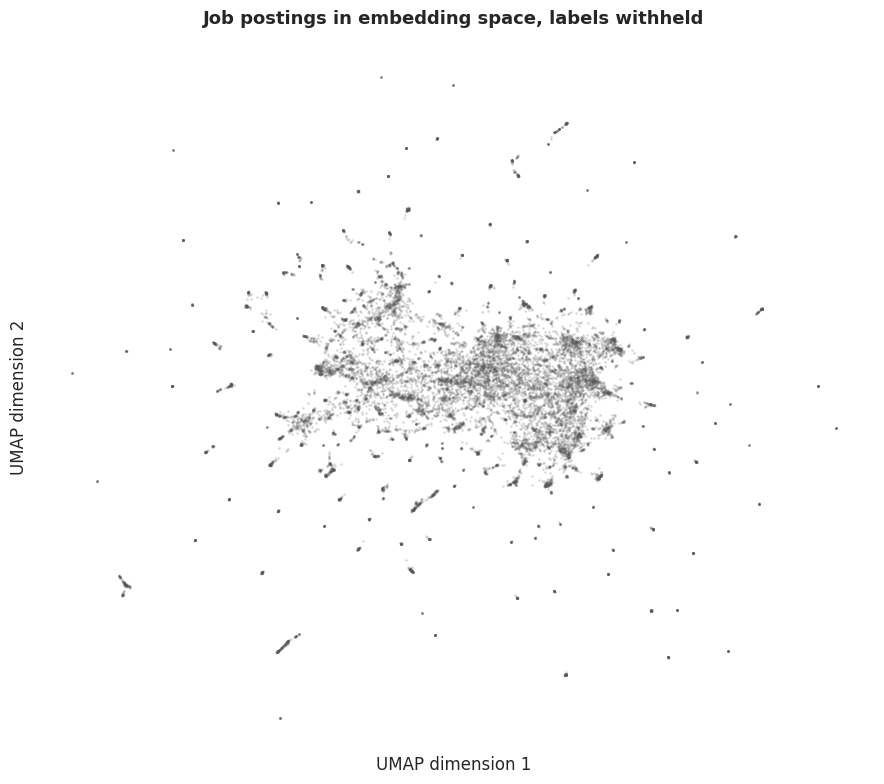

In [11]:
# Reduce twice: a working space for clustering, a flat map for looking
UMAP_NEIGHBORS = 15
CLUSTER_DIMS = 5

reducer_cluster = umap.UMAP(n_neighbors=UMAP_NEIGHBORS,
                            min_dist=0.0,
                            n_components=CLUSTER_DIMS,
                            metric='cosine',
                            random_state=RANDOM_STATE)
X_cluster = reducer_cluster.fit_transform(embeddings)
print(f'🧮 Clustering space: {X_cluster.shape[0]:,} x {X_cluster.shape[1]}')

reducer_map = umap.UMAP(n_neighbors=UMAP_NEIGHBORS,
                        min_dist=0.1,
                        n_components=2,
                        metric='cosine',
                        random_state=RANDOM_STATE)
X_map = reducer_map.fit_transform(embeddings)
print(f'🗺️ Visualization space: {X_map.shape[0]:,} x {X_map.shape[1]}')

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(X_map[:, 0], X_map[:, 1], s=3, c=DARK_GRAY, alpha=0.25, linewidths=0)
ax.set_title('Job postings in embedding space, labels withheld',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('UMAP dimension 1')
ax.set_ylabel('UMAP dimension 2')
ax.set_xticks([])
ax.set_yticks([])
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('umap_unlabeled.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Sweep min_cluster_size using internal measures only, labels still withheld
sweep = []
for mcs in [10, 15, 25, 40, 60, 100]:
    clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs,
                                min_samples=5,
                                metric='euclidean',
                                cluster_selection_method='eom')
    labels = clusterer.fit_predict(X_cluster)
    clustered = labels >= 0
    n_clusters = int(labels.max()) + 1
    sizes = pd.Series(labels[clustered]).value_counts()
    sil = np.nan
    if n_clusters > 1:
        sil = silhouette_score(X_cluster[clustered], labels[clustered],
                               sample_size=5_000, random_state=RANDOM_STATE)
    sweep.append({'min_cluster_size': mcs,
                  'clusters': n_clusters,
                  'noise_share': 1 - clustered.mean(),
                  'silhouette': sil,
                  'median_cluster': sizes.median(),
                  'largest_cluster': sizes.max()})

print('🔬 HDBSCAN sweep, fraud labels still withheld')
display(pd.DataFrame(sweep))

🔬 HDBSCAN sweep, fraud labels still withheld


,min_cluster_size,clusters,noise_share,silhouette,median_cluster,largest_cluster
0,10,411,0.2826,0.7012,20.0000,269
1,15,280,0.2840,0.6831,27.5000,327
2,25,173,0.3141,0.6507,47.0000,327
3,40,108,0.3745,0.6286,69.0000,335
4,60,64,0.3607,0.5297,111.5000,750
5,100,36,0.4379,0.5394,173.0000,769


In [13]:
# Fit the chosen clustering, labels still withheld
MIN_CLUSTER_SIZE = 25
MIN_SAMPLES = 5

clusterer = hdbscan.HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE,
                            min_samples=MIN_SAMPLES,
                            metric='euclidean',
                            cluster_selection_method='eom',
                            prediction_data=True)

df['cluster'] = clusterer.fit_predict(X_cluster)
df['cluster_prob'] = clusterer.probabilities_

clustered = df['cluster'] >= 0
n_clusters = int(df['cluster'].max()) + 1
sizes = df.loc[clustered, 'cluster'].value_counts()

print(f'🧩 Clusters found: {n_clusters:,}')
print(f'🌫️ Noise: {(~clustered).sum():,} postings ({(~clustered).mean():.1%})')
print(f'📐 Cluster sizes: median {sizes.median():,.0f} | '
      f'smallest {sizes.min():,} | largest {sizes.max():,}')
print(f'🎯 Mean membership confidence: {df.loc[clustered, "cluster_prob"].mean():.3f}')
print(f'\n📊 Ten largest clusters:')
print(sizes.head(10).to_string())

🧩 Clusters found: 173
🌫️ Noise: 4,985 postings (31.4%)
📐 Cluster sizes: median 47 | smallest 25 | largest 327
🎯 Mean membership confidence: 0.803

📊 Ten largest clusters:
cluster
166    327
152    325
130    269
161    223
159    219
154    189
172    185
77     156
150    149
74     144


In [14]:
# Stability check: does the structure survive a different UMAP seed?
def cluster_at_seed(seed):
    reducer = umap.UMAP(n_neighbors=UMAP_NEIGHBORS,
                        min_dist=0.0,
                        n_components=CLUSTER_DIMS,
                        metric='cosine',
                        random_state=seed)
    space = reducer.fit_transform(embeddings)
    model = hdbscan.HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE,
                            min_samples=MIN_SAMPLES,
                            metric='euclidean',
                            cluster_selection_method='eom')
    return model.fit_predict(space)


SEEDS = [RANDOM_STATE, 7, 2026]
runs = {}

for seed in SEEDS:
    labels = (df['cluster'].to_numpy() if seed == RANDOM_STATE
              else cluster_at_seed(seed))
    runs[seed] = labels
    print(f'🌱 seed {seed:>5,}: {int(labels.max()) + 1:>3,} clusters | '
          f'noise {(labels < 0).mean():.1%}')

print('\n🔁 Agreement between runs, on postings clustered in both:')
for i, a in enumerate(SEEDS):
    for b in SEEDS[i + 1:]:
        both = (runs[a] >= 0) & (runs[b] >= 0)
        print(f'   seed {a:,} vs {b:,}: '
              f'ARI {adjusted_rand_score(runs[a][both], runs[b][both]):.3f} | '
              f'NMI {normalized_mutual_info_score(runs[a][both], runs[b][both]):.3f} '
              f'(on {both.sum():,} postings)')

🌱 seed    42: 173 clusters | noise 31.4%
🌱 seed     7: 172 clusters | noise 29.1%
🌱 seed 2,026: 190 clusters | noise 31.0%

🔁 Agreement between runs, on postings clustered in both:
   seed 42 vs 7: ARI 0.937 | NMI 0.977 (on 9,845 postings)
   seed 42 vs 2,026: ARI 0.915 | NMI 0.978 (on 9,757 postings)
   seed 7 vs 2,026: ARI 0.898 | NMI 0.971 (on 9,779 postings)


In [15]:
# Reveal the withheld labels and measure concentration
base_rate = df['fraudulent'].mean()
total_fraud = int(df['fraudulent'].sum())
noise_mask = df['cluster'] < 0

profile = (df[~noise_mask]
           .groupby('cluster')
           .agg(size=('fraudulent', 'size'),
                fraud=('fraudulent', 'sum'),
                fraud_rate=('fraudulent', 'mean'))
           .sort_values('fraud_rate', ascending=False))
profile['lift'] = profile['fraud_rate'] / base_rate

print(f'📊 Base fraud rate: {base_rate:.2%}')
print(f'🌫️ Fraud rate among noise: {df.loc[noise_mask, "fraudulent"].mean():.2%} '
      f'({int(df.loc[noise_mask, "fraudulent"].sum()):,} of {int(noise_mask.sum()):,})')

print(f'\n🎯 Clusters above base rate: '
      f'{int((profile["fraud_rate"] > base_rate).sum()):,} of {len(profile):,}')
print(f'🔥 Clusters at 3x base or higher: {int((profile["lift"] >= 3).sum()):,}')
print(f'🔥 Clusters at 5x base or higher: {int((profile["lift"] >= 5).sum()):,}')

enriched = profile[profile['lift'] >= 3]
print(f'\n📦 Fraud sitting in 3x+ clusters: {int(enriched["fraud"].sum()):,} '
      f'of {total_fraud:,} ({enriched["fraud"].sum() / total_fraud:.1%})')
print(f'📐 Those clusters hold {int(enriched["size"].sum()):,} postings, '
      f'{enriched["size"].sum() / len(df):.1%} of the data')

print('\n🏆 Fifteen most fraud-dense clusters:')
display(profile.head(15))

📊 Base fraud rate: 4.48%
🌫️ Fraud rate among noise: 4.01% (200 of 4,985)

🎯 Clusters above base rate: 35 of 173
🔥 Clusters at 3x base or higher: 15
🔥 Clusters at 5x base or higher: 9

📦 Fraud sitting in 3x+ clusters: 302 of 711 (42.5%)
📐 Those clusters hold 910 postings, 5.7% of the data

🏆 Fifteen most fraud-dense clusters:


,size,fraud,fraud_rate,lift
cluster,,,,
66,31,30,0.9677,21.6034
35,40,36,0.9000,20.0911
138,27,19,0.7037,15.7091
114,89,50,0.5618,12.5413
67,33,14,0.4242,9.4706
139,131,47,0.3588,8.0092
113,28,8,0.2857,6.3781
137,71,17,0.2394,5.3451
123,42,10,0.2381,5.3151


In [16]:
# What language defines the fraud-dense clusters?
FRAUD_CLUSTERS = profile[profile['lift'] >= 3].index.tolist()

cluster_docs = (df[df['cluster'] >= 0]
                .groupby('cluster')['document']
                .apply(' '.join))

vectorizer = TfidfVectorizer(max_features=20_000, stop_words='english',
                             ngram_range=(1, 2), min_df=2)
cluster_matrix = vectorizer.fit_transform(cluster_docs)
terms = np.array(vectorizer.get_feature_names_out())

print('🔤 Distinguishing terms, fraud-dense clusters\n')
for cid in FRAUD_CLUSTERS:
    row = cluster_matrix[cluster_docs.index.get_loc(cid)].toarray().ravel()
    top_terms = terms[np.argsort(row)[-12:][::-1]]
    stats = profile.loc[cid]
    print(f'cluster {cid:>3} | {int(stats["size"]):>3,} postings | '
          f'fraud {stats["fraud_rate"]:>6.1%} ({stats["lift"]:>4.1f}x)')
    print(f'   {", ".join(redact_terms(top_terms))}\n')

🔤 Distinguishing terms, fraud-dense clusters

cluster  66 |  31 postings | fraud  96.8% (21.6x)
   work, data entry, little guidance, variety career, home, typing, legitimate, skills relevant, limited data, entry customer, entry, seeking individuals

cluster  35 |  40 postings | fraud  90.0% (20.1x)
   extra day, free time, cash, time, day experience, experience required, home free, work morning, 30 minutes, 400, required, free

cluster 138 |  27 postings | fraud  70.4% (15.7x)
   data entry, data, entry, customer account, entry clerk, clerk, customer, incomplete, insurance employee, information, inputting, ad insurance

cluster 114 |  89 postings | fraud  56.2% (12.5x)
   oil gas, oil, engineering, design, gas, gas industry, people values, field employ, employ approximately, production maximize

cluster  67 |  33 postings | fraud  42.4% ( 9.5x)
   income, business, mso, work, home, money, time, earn, webcam, parents, earning, opportunity

cluster 139 | 131 postings | fraud  35.9% ( 8.

In [17]:
# Structural profile of the fraud-dense clusters against the corpus baseline
STRUCT = ['doc_length', 'n_copies', 'n_contact_tokens', 'has_company_profile',
          'has_requirements', 'has_benefits', 'has_salary',
          'telecommuting', 'has_company_logo', 'has_questions']

print('📋 Corpus baseline:')
print(df[STRUCT].mean().to_string())

struct = (df[df['cluster'].isin(FRAUD_CLUSTERS)]
          .groupby('cluster')[STRUCT]
          .mean()
          .join(profile[['size', 'fraud_rate', 'lift']])
          .sort_values('lift', ascending=False))

print('\n🏗️ Fraud-dense clusters:')
display(struct)

📋 Corpus baseline:
doc_length            391.9686
n_copies                1.1264
n_contact_tokens        0.6762
has_company_profile     0.8074
has_requirements        0.8586
has_benefits            0.5857
has_salary              0.1696
telecommuting           0.0422
has_company_logo        0.7998
has_questions           0.4907

🏗️ Fraud-dense clusters:


,doc_length,n_copies,n_contact_tokens,has_company_profile,has_requirements,has_benefits,has_salary,telecommuting,has_company_logo,has_questions,size,fraud_rate,lift
cluster,,,,,,,,,,,,,
66,128.6129,2.2581,0.4839,0.0000,0.9677,0.2903,0.1290,0.6452,0.0968,0.0323,31,0.9677,21.6034
35,68.6000,1.0250,0.9250,0.0000,0.7750,0.5000,0.0250,0.0000,0.0000,0.0750,40,0.9000,20.0911
138,192.4444,1.1481,0.4444,0.1481,0.7407,0.8148,0.5185,0.1111,0.1111,0.1481,27,0.7037,15.7091
114,408.7640,1.1011,0.8315,0.5169,0.8202,0.3708,0.0449,0.0225,0.5393,0.1573,89,0.5618,12.5413
67,280.3636,1.1515,0.9394,0.4545,0.8182,0.8182,0.0606,0.4545,0.6364,0.6970,33,0.4242,9.4706
139,243.6718,1.0763,0.3817,0.4504,0.8702,0.5573,0.3206,0.0534,0.4733,0.4351,131,0.3588,8.0092
113,388.6786,1.0000,0.7143,0.6429,0.7857,0.1786,0.1429,0.0000,0.5714,0.3571,28,0.2857,6.3781
137,393.9155,1.0141,1.1972,0.8732,0.9296,0.7324,0.2535,0.0282,0.8592,0.5634,71,0.2394,5.3451
123,248.2381,1.0238,0.6190,0.6190,0.7619,0.7143,0.4286,0.0476,0.6190,0.5000,42,0.2381,5.3151


In [18]:
# Read the most representative postings from each fraud-dense cluster
def show_cluster(cid, n=3, chars=450):
    stats = profile.loc[cid]
    members = df[df['cluster'] == cid].nlargest(n, 'cluster_prob')
    print(f'\n{"." * 70}')
    print(f'cluster {cid} | {int(stats["size"]):,} postings | '
          f'fraud {stats["fraud_rate"]:.1%} ({stats["lift"]:.1f}x)')
    for _, row in members.iterrows():
        flag = '🚩' if row['fraudulent'] else '✅'
        print(f'\n   {flag} {redact(row["title"])} | {row["location"]}')
        print(f'      {redact(row["document"])[:chars]}...')


for cid in [66, 35, 138, 67, 114, 137, 139, 74]:
    show_cluster(cid)


......................................................................
cluster 66 | 31 postings | fraud 96.8% (21.6x)

   🚩 Home Based Commission Roles | US, IN, 
      Home Based Commission Roles A Variety of Commission based jobs available.Visit: weblink Internet AccessHome PC or LaptopCommitment Great CommissionBe you own BossHours to Suit...

   🚩 Admin Clerk Remote Position | US, SC, Columbia
      Admin Clerk Remote Position We are seeking individuals to be connected with companies who are hiring employees directly to work from their homes. You will find both full-time and part-time opportunities in a variety of career fields including but not limited to: data entry, customer support, billing, typing, and administrative.These positions guarantee wages ranging from $12 per hour up to six figure salary. This includes bonuses, benefits, and f...

   🚩 Remote Admin Clerk | US, KY, Lexington
      Remote Admin Clerk We are seeking individuals to be connected with companies who are hi

In [19]:
# A common yardstick: how much fraud does a clustering concentrate, and how tightly?
def concentration_report(labels, name, lift_threshold=3.0):
    """Share of fraud captured by clusters running at lift x the base rate."""
    frame = pd.DataFrame({'cluster': np.asarray(labels),
                          'fraudulent': df['fraudulent'].to_numpy()})
    base = frame['fraudulent'].mean()
    total_fraud = int(frame['fraudulent'].sum())

    per_cluster = (frame[frame['cluster'] >= 0]
                   .groupby('cluster')['fraudulent']
                   .agg(size='size', fraud='sum', fraud_rate='mean'))
    per_cluster['lift'] = per_cluster['fraud_rate'] / base

    hot = per_cluster[per_cluster['lift'] >= lift_threshold]
    captured = hot['fraud'].sum() / total_fraud
    occupied = hot['size'].sum() / len(frame)

    return {'method': name,
            'clusters': len(per_cluster),
            'unassigned': f'{(frame["cluster"] < 0).mean():.1%}',
            'hot_clusters': len(hot),
            'fraud_captured': f'{captured:.1%}',
            'data_occupied': f'{occupied:.1%}',
            'concentration': round(captured / max(occupied, 1e-9), 1)}


comparison = [concentration_report(df['cluster'].to_numpy(), 'HDBSCAN on embeddings')]
display(pd.DataFrame(comparison))

,method,clusters,unassigned,hot_clusters,fraud_captured,data_occupied,concentration
0,HDBSCAN on embeddings,173,31.4%,15,42.5%,5.7%,7.4000


In [20]:
# K-means on the same reduced space, k selected by silhouette
kmeans_runs = {}
kmeans_rows = []

for k in [10, 25, 50, 100, 173]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    kmeans_runs[k] = labels

    row = concentration_report(labels, f'K-means k={k}')
    row['silhouette'] = round(silhouette_score(X_cluster, labels,
                                               sample_size=5_000,
                                               random_state=RANDOM_STATE), 3)
    kmeans_rows.append(row)

print('🔬 K-means sweep on the UMAP embedding space')
display(pd.DataFrame(kmeans_rows))

🔬 K-means sweep on the UMAP embedding space


,method,clusters,unassigned,hot_clusters,fraud_captured,data_occupied,concentration,silhouette
0,K-means k=10,10,0.0%,0,0.0%,0.0%,0.0000,0.3240
1,K-means k=25,25,0.0%,2,52.0%,15.1%,3.4000,0.3410
2,K-means k=50,50,0.0%,3,47.8%,10.8%,4.4000,0.3670
3,K-means k=100,100,0.0%,6,51.1%,9.2%,5.5000,0.4650
4,K-means k=173,173,0.0%,12,55.8%,8.2%,6.8000,0.5020


In [21]:
# TF-IDF baseline: same pipeline shape, word counts instead of sentence embeddings
tfidf = TfidfVectorizer(max_features=50_000, stop_words='english',
                        ngram_range=(1, 2), min_df=5, sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df['document'])
print(f'🔤 TF-IDF matrix: {X_tfidf.shape[0]:,} x {X_tfidf.shape[1]:,}')

svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_tfidf)
print(f'📉 SVD to {X_svd.shape[1]} components, '
      f'variance explained {svd.explained_variance_ratio_.sum():.1%}')

reducer_tfidf = umap.UMAP(n_neighbors=UMAP_NEIGHBORS, min_dist=0.0,
                          n_components=CLUSTER_DIMS, metric='cosine',
                          random_state=RANDOM_STATE)
X_tfidf_cluster = reducer_tfidf.fit_transform(X_svd)

hdb_tfidf = hdbscan.HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE,
                            min_samples=MIN_SAMPLES,
                            metric='euclidean',
                            cluster_selection_method='eom').fit_predict(X_tfidf_cluster)
km_tfidf = KMeans(n_clusters=173, random_state=RANDOM_STATE,
                  n_init=10).fit_predict(X_tfidf_cluster)

comparison = [concentration_report(df['cluster'].to_numpy(), 'HDBSCAN on embeddings'),
              concentration_report(kmeans_runs[173], 'K-means k=173, embeddings'),
              concentration_report(hdb_tfidf, 'HDBSCAN, TF-IDF'),
              concentration_report(km_tfidf, 'K-means k=173, TF-IDF')]

print('\n🧪 Representation and algorithm comparison')
display(pd.DataFrame(comparison))

🔤 TF-IDF matrix: 15,872 x 50,000
📉 SVD to 100 components, variance explained 23.0%

🧪 Representation and algorithm comparison


,method,clusters,unassigned,hot_clusters,fraud_captured,data_occupied,concentration
0,HDBSCAN on embeddings,173,31.4%,15,42.5%,5.7%,7.4000
1,"K-means k=173, embeddings",173,0.0%,12,55.8%,8.2%,6.8000
2,"HDBSCAN, TF-IDF",190,27.3%,18,61.0%,6.6%,9.3000
3,"K-means k=173, TF-IDF",173,0.0%,10,67.7%,9.7%,7.0000


In [22]:
# Do the two representations catch the same fraud or complementary fraud?
base_rate = df['fraudulent'].mean()

def hot_mask(labels, threshold=3.0):
    frame = pd.DataFrame({'c': np.asarray(labels), 'f': df['fraudulent'].to_numpy()})
    rates = frame[frame['c'] >= 0].groupby('c')['f'].mean()
    hot_ids = set(rates[rates / base_rate >= threshold].index)
    return frame['c'].isin(hot_ids).to_numpy()

emb_hot = hot_mask(df['cluster'].to_numpy())
tfidf_hot = hot_mask(hdb_tfidf)
is_fraud = df['fraudulent'].to_numpy().astype(bool)
total = int(is_fraud.sum())

print('🧭 Where the 711 fraudulent postings land')
print(f'   🟢 caught by both:        {int((is_fraud & emb_hot & tfidf_hot).sum()):>4,}')
print(f'   🔵 embeddings only:       {int((is_fraud & emb_hot & ~tfidf_hot).sum()):>4,}')
print(f'   🟠 TF-IDF only:           {int((is_fraud & ~emb_hot & tfidf_hot).sum()):>4,}')
print(f'   ⚪ caught by neither:     {int((is_fraud & ~emb_hot & ~tfidf_hot).sum()):>4,}')

union = is_fraud & (emb_hot | tfidf_hot)
union_data = (emb_hot | tfidf_hot)
print(f'\n🤝 Union: {int(union.sum()):,} of {total:,} fraud '
      f'({union.sum() / total:.1%}) in {union_data.mean():.1%} of the data '
      f'(concentration {(union.sum() / total) / union_data.mean():.1f})')

🧭 Where the 711 fraudulent postings land
   🟢 caught by both:         226
   🔵 embeddings only:         76
   🟠 TF-IDF only:            208
   ⚪ caught by neither:      201

🤝 Union: 510 of 711 fraud (71.7%) in 9.8% of the data (concentration 7.3)


In [23]:
# Profile the TF-IDF clusters and surface what the embeddings missed
df['cluster_tfidf'] = hdb_tfidf
is_fraud = df['fraudulent'].astype(bool)
df['caught_by_embeddings'] = is_fraud & emb_hot

tfidf_profile = (df[df['cluster_tfidf'] >= 0]
                 .groupby('cluster_tfidf')
                 .agg(size=('fraudulent', 'size'),
                      fraud=('fraudulent', 'sum'),
                      fraud_rate=('fraudulent', 'mean')))
tfidf_profile['lift'] = tfidf_profile['fraud_rate'] / base_rate
tfidf_profile['new_fraud'] = (df[(df['cluster_tfidf'] >= 0) & is_fraud
                                 & ~df['caught_by_embeddings']]
                              .groupby('cluster_tfidf').size())
tfidf_profile['new_fraud'] = tfidf_profile['new_fraud'].fillna(0).astype(int)

hot_tfidf = (tfidf_profile[tfidf_profile['lift'] >= 3]
             .sort_values('new_fraud', ascending=False))
print(f'🔥 TF-IDF hot clusters: {len(hot_tfidf):,}')
display(hot_tfidf)

tfidf_docs = (df[df['cluster_tfidf'] >= 0]
              .groupby('cluster_tfidf')['document'].apply(' '.join))
ctf_vectorizer = TfidfVectorizer(max_features=20_000, stop_words='english',
                                 ngram_range=(1, 2), min_df=2)
ctf_matrix = ctf_vectorizer.fit_transform(tfidf_docs)
ctf_terms = np.array(ctf_vectorizer.get_feature_names_out())

print('\n🔤 Distinguishing terms, ranked by fraud the embeddings missed\n')
for cid in hot_tfidf.head(8).index:
    row = ctf_matrix[tfidf_docs.index.get_loc(cid)].toarray().ravel()
    top_terms = ctf_terms[np.argsort(row)[-12:][::-1]]
    s = hot_tfidf.loc[cid]
    print(f'cluster {cid:>3} | {int(s["size"]):>3,} postings | '
          f'fraud {s["fraud_rate"]:>6.1%} ({s["lift"]:>4.1f}x) | '
          f'{int(s["new_fraud"]):>3,} newly caught')
    print(f'   {", ".join(redact_terms(top_terms))}\n')

🔥 TF-IDF hot clusters: 18


,size,fraud,fraud_rate,lift,new_fraud
cluster_tfidf,,,,,
41,35,35,1.0000,22.3235,31
37,62,62,1.0000,22.3235,29
171,89,34,0.3820,8.5281,23
170,93,60,0.6452,14.4023,19
144,103,25,0.2427,5.4183,18
165,58,20,0.3448,7.6978,15
166,129,27,0.2093,4.6724,12
106,29,11,0.3793,8.4675,11
162,25,10,0.4000,8.9294,9



🔤 Distinguishing terms, ranked by fraud the embeddings missed

cluster  41 |  35 postings | fraud 100.0% (22.3x) |  31 newly caught
   refined, equipment, technician, plant, project, candidates encouraged, environmental, signing, oil

cluster  37 |  62 postings | fraud 100.0% (22.3x) |  29 newly caught
   product, experience, signing bonus, employees receive, leveraging career, engineering, signing, team, new, staffing solutions

cluster 171 |  89 postings | fraud  38.2% ( 8.5x) |  23 newly caught
   church, administrative, office, assistant, data, skills, administrative assistant, work, experience, data entry, customer account, company

cluster 170 |  93 postings | fraud  64.5% (14.4x) |  19 newly caught
   data entry, entry, skills, administrative, office, work, assistant, data, clerk, administrative assistant, experience, excel

cluster 144 | 103 postings | fraud  24.3% ( 5.4x) |  18 newly caught
   home health, patient, patients, care, home, health, nursing, hospital, patient care

In [24]:
# Read the pure-fraud TF-IDF clusters
def show_tfidf_cluster(cid, n=3, chars=450):
    s = hot_tfidf.loc[cid]
    members = df[df['cluster_tfidf'] == cid].sample(min(n, int(s['size'])),
                                                    random_state=RANDOM_STATE)
    row_idx = tfidf_docs.index.get_loc(cid)
    top_terms = ctf_terms[np.argsort(ctf_matrix[row_idx].toarray().ravel())[-12:][::-1]]

    print(f'\n{"." * 70}')
    print(f'cluster {cid} | {int(s["size"]):,} postings | '
          f'fraud {s["fraud_rate"]:.1%} ({s["lift"]:.1f}x) | '
          f'{int(s["new_fraud"]):,} newly caught')
    print(f'   terms: {", ".join(redact_terms(top_terms))}')

    for _, row in members.iterrows():
        flag = '🚩' if row['fraudulent'] else '✅'
        print(f'\n   {flag} {redact(row["title"])} | {row["location"]}')
        print(f'      {redact(row["document"])[:chars]}...')


for cid in [41, 37, 2, 170, 171, 106]:
    show_tfidf_cluster(cid)


......................................................................
cluster 41 | 35 postings | fraud 100.0% (22.3x) | 31 newly caught
   terms: refined, equipment, technician, plant, project, candidates encouraged, environmental, signing, oil

   🚩 Process Engineer | US, CA, Bakersfield
      Process Engineer Staffing & Recruiting done right for the Oil & Energy Industry!Represented candidates are automatically granted the following perks: Expert negotiations on your behalf, maximizing your compensation package and implimenting ongoing increases Significant signing bonus by [IDENTITY REDACTED] (in addition to any potential signing bonuses our client companies offer)1 Year access to AnyPerk: significant corporate discounts on cell phon...

   🚩 Process Safety Engineer | US, CA, Bakersfield
      Process Safety Engineer Process Unlimited and [IDENTITY REDACTED] have partnered up in an effort to streamline the hiring process and provide a more efficient and effective recruitng model. 

In [25]:
# Do the agency clusters share template language?
PHRASES = ['leveraging your career',
           'redesigned the recruiting wheel',
           'have partnered up in an effort to streamline',
           'Represented candidates']

for phrase in PHRASES:
    hit = df['document'].str.contains(phrase, case=False, na=False, regex=False)
    if hit.sum():
        print(f'\n🔎 "{phrase}": {hit.sum():,} postings | '
              f'fraud {df.loc[hit, "fraudulent"].mean():.1%}')
        print(df.loc[hit, 'cluster_tfidf'].value_counts().head(5).to_string())


🔎 "leveraging your career": 78 postings | fraud 100.0%
cluster_tfidf
 37     59
 41     16
 148     1
-1       1
 173     1

🔎 "redesigned the recruiting wheel": 35 postings | fraud 100.0%
cluster_tfidf
37    35

🔎 "have partnered up in an effort to streamline": 43 postings | fraud 100.0%
cluster_tfidf
 37     24
 41     16
 148     1
-1       1
 173     1

🔎 "Represented candidates": 56 postings | fraud 100.0%
cluster_tfidf
37    37
41    19


In [26]:
# Size the campaign across all its template phrases
campaign_mask = np.zeros(len(df), dtype=bool)
for phrase in PHRASES:
    campaign_mask |= df['document'].str.contains(phrase, case=False,
                                                 na=False, regex=False).to_numpy()

hits = df[campaign_mask]
print(f'🎯 Campaign footprint: {len(hits):,} postings')
print(f'🚩 Fraud rate: {hits["fraudulent"].mean():.1%}')
print(f'📦 Share of all fraud in the corpus: '
      f'{hits["fraudulent"].sum() / df["fraudulent"].sum():.1%}')
print(f'🏷️ Distinct job titles: {hits["title"].nunique():,}')
print(f'🌍 Distinct locations: {hits["location"].nunique():,}')
print(f'📄 Pre-dedupe copies: {hits["n_copies"].sum():,}')
print('\n📍 Clusters it spans:')
print(hits['cluster_tfidf'].value_counts().to_string())

🎯 Campaign footprint: 99 postings
🚩 Fraud rate: 100.0%
📦 Share of all fraud in the corpus: 13.9%
🏷️ Distinct job titles: 60
🌍 Distinct locations: 22
📄 Pre-dedupe copies: 99

📍 Clusters it spans:
cluster_tfidf
 37     61
 41     35
 148     1
-1       1
 173     1


In [27]:
# Assign postings to archetypes, in precedence order, and summarize
df['archetype'] = pd.NA

df.loc[campaign_mask, 'archetype'] = 'The Ghost Agency'
df.loc[df['archetype'].isna() & df['cluster_tfidf'].isin([2]),
       'archetype'] = 'The Borrowed Brand'
df.loc[df['archetype'].isna() & df['cluster'].isin([66, 35]),
       'archetype'] = 'The Bait Ad'
df.loc[df['archetype'].isna() & df['cluster_tfidf'].isin([170, 171]),
       'archetype'] = 'The Common Form'
df.loc[df['archetype'].isna() & df['cluster'].isin([138, 139, 67]),
       'archetype'] = 'The Common Form'

named = df[df['archetype'].notna()]
summary = (named.groupby('archetype')
           .agg(postings=('fraudulent', 'size'),
                fraud=('fraudulent', 'sum'),
                fraud_rate=('fraudulent', 'mean'),
                median_words=('doc_length', 'median'),
                job_titles=('title', 'nunique'),
                has_profile=('has_company_profile', 'mean'),
                has_logo=('has_company_logo', 'mean'),
                has_questions=('has_questions', 'mean')))
summary['lift'] = summary['fraud_rate'] / base_rate
summary['pct_of_all_fraud'] = summary['fraud'] / df['fraudulent'].sum()

print(f'🏷️ Postings assigned to an archetype: {len(named):,} '
      f'({len(named) / len(df):.1%} of the corpus)')
print(f'🚩 Fraud they account for: {int(named["fraudulent"].sum()):,} '
      f'of {int(df["fraudulent"].sum()):,} '
      f'({named["fraudulent"].sum() / df["fraudulent"].sum():.1%})')
print('\n📋 Corpus baseline for comparison:')
print(f'   median words {df["doc_length"].median():,.0f} | '
      f'profile {df["has_company_profile"].mean():.1%} | '
      f'logo {df["has_company_logo"].mean():.1%} | '
      f'questions {df["has_questions"].mean():.1%}')
display(summary)

🏷️ Postings assigned to an archetype: 504 (3.2% of the corpus)
🚩 Fraud they account for: 338 of 711 (47.5%)

📋 Corpus baseline for comparison:
   median words 366 | profile 80.7% | logo 80.0% | questions 49.1%


,postings,fraud,fraud_rate,median_words,job_titles,has_profile,has_logo,has_questions,lift,pct_of_all_fraud
archetype,,,,,,,,,,
The Bait Ad,71,66,0.9296,81.0000,69,0.0000,0.0423,0.0563,20.7514,0.0928
The Borrowed Brand,51,51,1.0000,514.0000,32,0.5882,0.5882,0.0000,22.3235,0.0717
The Common Form,283,122,0.4311,208.0000,200,0.3675,0.4064,0.4028,9.6236,0.1716
The Ghost Agency,99,99,1.0000,571.0000,60,1.0000,1.0000,0.8990,22.3235,0.1392


In [28]:
# Figures for the white paper

FIG_DIR = Path('/content/drive/MyDrive/DSC680/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

LIFT_THRESHOLD = 3.0
base = df['fraudulent'].mean()
total_fraud = int(df['fraudulent'].sum())

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 110,
})


def save_figure(fig, name):
    fig.savefig(FIG_DIR / name, dpi=200, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    print(f'   saved {name}')


def cluster_profile(column):
    frame = df.loc[df[column] >= 0, [column, 'fraudulent']]
    out = frame.groupby(column)['fraudulent'].agg(size='size', fraud='sum', rate='mean')
    out['lift'] = out['rate'] / base
    return out


def hot_mask(column):
    prof = cluster_profile(column)
    hot_ids = prof.index[prof['lift'] >= LIFT_THRESHOLD]
    return df[column].isin(hot_ids).to_numpy(), list(hot_ids)


print('Building figures')

# Figure 1, the shape of the space with no labels attached
fig, ax = plt.subplots(figsize=(7.5, 6.2))
ax.scatter(X_map[:, 0], X_map[:, 1], s=3, c=LIGHT_GRAY, alpha=0.7, linewidths=0)
ax.set_title('Postings fall into one dense crowd ringed by small, tight satellites', pad=14)
ax.text(0.0, 1.015, f'{len(df):,} postings in two dimensional embedding space, fraud labels withheld',
        transform=ax.transAxes, fontsize=9, color=DARK_GRAY)
ax.set_xticks([])
ax.set_yticks([])
for side in ax.spines.values():
    side.set_visible(False)
save_figure(fig, 'fig1_embedding_space.png')

# Figure 2, where the fraud actually sits
prof = cluster_profile('cluster').sort_values('rate', ascending=False)
colors = [ROYAL_BLUE if lift >= LIFT_THRESHOLD else LIGHT_GRAY for lift in prof['lift']]
n_hot = int((prof['lift'] >= LIFT_THRESHOLD).sum())

x_limit = int((prof['rate'] > 0).sum()) + 2

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.bar(range(len(prof)), prof['rate'] * 100, color=colors, width=1.0)
ax.axhline(base * 100, color=DARK_GRAY, linestyle='--', linewidth=1.2)
ax.text(x_limit * 0.99, base * 100 + 1.5, f'corpus base rate, {base * 100:.1f}%',
        ha='right', fontsize=9, color=DARK_GRAY)
ax.set_title(f'{n_hot} of {len(prof)} clusters carry fraud at three times the base rate or more', pad=14)
ax.set_xlabel('HDBSCAN clusters, ordered by fraud rate')
ax.set_ylabel('Fraud rate (%)')
ax.set_xlim(-1, x_limit)
ax.set_ylim(0, 105)
ax.legend(handles=[Patch(facecolor=ROYAL_BLUE, label=f'Lift at or above {LIFT_THRESHOLD:.0f}'),
                   Patch(facecolor=LIGHT_GRAY, label='Below threshold')],
          frameon=False, fontsize=9, loc='upper right')
save_figure(fig, 'fig2_fraud_rate_by_cluster.png')

# Figure 3, what each representation buys you per unit of review
emb_m, emb_ids = hot_mask('cluster')
tfidf_m, tfidf_ids = hot_mask('cluster_tfidf')
union_m = emb_m | tfidf_m

reach = []
for name, mask in [('Embeddings', emb_m), ('TF-IDF', tfidf_m), ('Union of both', union_m)]:
    captured = df.loc[mask, 'fraudulent'].sum() / total_fraud * 100
    occupied = mask.mean() * 100
    reach.append({'method': name, 'captured': captured, 'occupied': occupied,
                  'concentration': captured / occupied})

reach_frame = pd.DataFrame(reach)
singles = reach_frame[reach_frame['method'] != 'Union of both']
best_single = singles.sort_values('concentration', ascending=False).iloc[0]
union_row = reach_frame[reach_frame['method'] == 'Union of both'].iloc[0]
added_capture = union_row['captured'] - best_single['captured']
added_corpus = union_row['occupied'] - best_single['occupied']
marginal = added_capture / added_corpus

positions = np.arange(len(reach_frame))
width = 0.36

fig, ax = plt.subplots(figsize=(8.5, 5.0))
bars_a = ax.bar(positions - width / 2, reach_frame['captured'], width,
                color=ROYAL_BLUE, label='Fraud captured')
bars_b = ax.bar(positions + width / 2, reach_frame['occupied'], width,
                color=LIGHT_GRAY, label='Share of corpus reviewed')
for bars in (bars_a, bars_b):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9, color=DARK_GRAY)
for idx, row in reach_frame.iterrows():
    ax.text(idx, -8, f'{row["concentration"]:.1f}x', ha='center', fontsize=10,
            color=FOREST_GREEN, fontweight='bold')
ax.text(-0.66, -8, 'concentration', ha='left', fontsize=9, color=DARK_GRAY)

ax.set_title(f'{best_single["method"]} is the most efficient single screen, '
             f'the union the most complete', pad=26)
ax.text(0.0, 1.035,
        f'Adding the second representation captures {added_capture:.1f} more points of fraud '
        f'for {added_corpus:.1f} more points of corpus, a marginal concentration of {marginal:.1f}x',
        transform=ax.transAxes, fontsize=9, color=DARK_GRAY)
ax.set_xticks(positions)
ax.set_xticklabels(reach_frame['method'])
ax.set_ylabel('Percent')
ax.set_ylim(0, 85)
ax.legend(frameon=False, fontsize=9)
save_figure(fig, 'fig3_capture_vs_review.png')

# Figure 4, structural completeness by archetype
presence = pd.DataFrame(index=df.index)
for column, label in [('company_profile', 'Company profile'),
                      ('requirements', 'Requirements'),
                      ('benefits', 'Benefits')]:
    if column in df.columns:
        presence[label] = df[column].fillna('').astype(str).str.strip().ne('')
if 'has_questions' in df.columns:
    presence['Screening questions'] = df['has_questions'].astype(int).eq(1)
if 'has_company_logo' in df.columns:
    presence['Company logo'] = df['has_company_logo'].astype(int).eq(1)

ARCHETYPE_ORDER = ['The Ghost Agency', 'The Borrowed Brand', 'The Bait Ad', 'The Common Form']
ARCHETYPE_COLORS = [ROYAL_BLUE, AMBER, FOREST_GREEN, PURPLE]
present_archetypes = [a for a in ARCHETYPE_ORDER if (df['archetype'] == a).any()]

features = list(presence.columns)
y_positions = np.arange(len(features))
series = [('Corpus baseline', LIGHT_GRAY)] + list(zip(present_archetypes, ARCHETYPE_COLORS))
bar_height = 0.82 / len(series)

fig, ax = plt.subplots(figsize=(9.0, 6.0))
for offset, (name, color) in enumerate(series):
    if name == 'Corpus baseline':
        rates = presence[features].mean() * 100
    else:
        rates = presence.loc[df['archetype'] == name, features].mean() * 100
    bar_y = y_positions + 0.41 - (offset + 0.5) * bar_height
    ax.barh(bar_y, rates.values, bar_height, color=color, label=name)
    for y, value in zip(bar_y, rates.values):
        ax.text(value + 1.5, y, f'{value:.0f}', va='center', fontsize=7.5, color=DARK_GRAY)

ax.set_title('Complete postings are not safe postings', pad=26)
ax.text(0.0, 1.035, 'Share of postings carrying each structural element, by archetype',
        transform=ax.transAxes, fontsize=9, color=DARK_GRAY)
ax.set_yticks(y_positions)
ax.set_yticklabels(features)
ax.set_xlabel('Percent of postings carrying the element')
ax.set_xlim(0, 112)
ax.set_ylim(len(features) - 0.5, -0.5)
ax.set_axisbelow(True)
ax.grid(False)
ax.xaxis.grid(True, color=LIGHT_GRAY, linewidth=0.6, alpha=0.6)
ax.legend(frameon=False, fontsize=9, ncol=len(series),
          loc='upper center', bbox_to_anchor=(0.5, -0.13))
save_figure(fig, 'fig4_archetype_fingerprint.png')

# Figure 5, one operator wearing many hats
campaign_titles = df.loc[campaign_mask, 'title'].map(redact).value_counts()
campaign_locations = df.loc[campaign_mask, 'location'].nunique() if 'location' in df.columns else 0
titles_per_count = campaign_titles.value_counts().sort_index()
once_only = int(titles_per_count.get(1, 0))

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11.0, 4.8),
                                        gridspec_kw={'width_ratios': [1, 1]})

ax_left.scatter(X_map[~campaign_mask, 0], X_map[~campaign_mask, 1],
                s=3, c=LIGHT_GRAY, alpha=0.5, linewidths=0)
ax_left.scatter(X_map[campaign_mask, 0], X_map[campaign_mask, 1],
                s=18, c=AMBER, alpha=0.95, linewidths=0)
ax_left.set_title('The campaign does not sit in one place', fontsize=11)
ax_left.set_xticks([])
ax_left.set_yticks([])
for side in ax_left.spines.values():
    side.set_visible(False)

ax_right.bar(titles_per_count.index, titles_per_count.values, color=AMBER, width=0.65)
for x, value in zip(titles_per_count.index, titles_per_count.values):
    ax_right.text(x, value + max(titles_per_count.values) * 0.02, str(value),
                  ha='center', fontsize=9, color=DARK_GRAY)
ax_right.set_title(f'{once_only} of {campaign_titles.shape[0]} titles appear exactly once',
                   fontsize=11)
ax_right.set_xlabel('Times a job title is reused')
ax_right.set_ylabel('Number of distinct titles')
ax_right.set_xticks(titles_per_count.index)
ax_right.set_ylim(0, max(titles_per_count.values) * 1.18)
ax_right.set_axisbelow(True)
ax_right.grid(False)
ax_right.yaxis.grid(True, color=LIGHT_GRAY, linewidth=0.6, alpha=0.6)

fig.suptitle(f'One operator, {int(campaign_mask.sum())} postings, '
             f'{campaign_titles.shape[0]} job titles, {campaign_locations} locations, '
             f'one shared paragraph',
             fontsize=12, fontweight='bold', y=1.02)
save_figure(fig, 'fig5_ghost_agency_campaign.png')

print()
print(f'📊 Five figures written to {FIG_DIR}')
print(f'🎯 Hot clusters: {len(emb_ids)} embedding, {len(tfidf_ids)} TF-IDF')
print(f'🔍 Union reviews {union_m.mean():.1%} of the corpus and captures '
      f'{df.loc[union_m, "fraudulent"].sum() / total_fraud:.1%} of the fraud')
print(f'🕵️ Campaign: {int(campaign_mask.sum())} postings, '
      f'{campaign_titles.shape[0]} titles, {campaign_locations} locations')

Building figures
   saved fig1_embedding_space.png
   saved fig2_fraud_rate_by_cluster.png
   saved fig3_capture_vs_review.png
   saved fig4_archetype_fingerprint.png
   saved fig5_ghost_agency_campaign.png

📊 Five figures written to /content/drive/MyDrive/DSC680/figures
🎯 Hot clusters: 15 embedding, 18 TF-IDF
🔍 Union reviews 9.8% of the corpus and captures 71.7% of the fraud
🕵️ Campaign: 99 postings, 60 titles, 22 locations
